<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 16px; margin-bottom: 10px;'>
  <h1 style='color: #e94560; font-size: 2.8em; margin: 0 0 10px 0; font-family: Georgia, serif; letter-spacing: 2px;'>Speech-to-Text Pipeline</h1>
  <h2 style='color: #a8dadc; font-size: 1.4em; margin: 0 0 20px 0; font-weight: 300;'>Task-Oriented Multimodal IR Agent — Audio Module</h2>
  <hr style='border: 1px solid #e94560; margin: 20px 0;'/>
  <table style='color: #ccc; font-size: 1em; width: 100%;'>
    <tr><td style='padding: 6px 0; width: 200px;'><b style='color: #e94560;'>Course</b></td><td>DS414 — Information Retrieval and Search Engines</td></tr>
    <tr><td style='padding: 6px 0;'><b style='color: #e94560;'>Lecturer</b></td><td>Dr. Ahmed Elshaer</td></tr>
    <tr><td style='padding: 6px 0;'><b style='color: #e94560;'>TA</b></td><td>Eng. Mazen Aziz</td></tr>
    <tr><td style='padding: 6px 0;'><b style='color: #e94560;'>Team</b></td><td>Ahmed Mohamed Hamimi · Ahmed Mohamed Abdelhamid · Omar Khaled</td></tr>
    <tr><td style='padding: 6px 0;'><b style='color: #e94560;'>Scope</b></td><td>Week 3 (Data Preprocessing) + Week 4 (Model Fine-Tuning)</td></tr>
  </table>
  <div style='margin-top: 25px; background: rgba(233,69,96,0.15); border-left: 4px solid #e94560; padding: 15px 20px; border-radius: 0 8px 8px 0;'>
    <p style='color: #eee; margin: 0; font-size: 0.95em;'><b>About this notebook:</b> This notebook covers the complete audio processing pipeline for the multimodal IR agent. Week 3 handles dataset loading, preprocessing, manifest generation, and DataLoader construction. Week 4 handles Wav2Vec2 fine-tuning with CTC loss, evaluation using WER and CER, and inference visualization. All data is assumed to be already extracted at the paths defined in the configuration cell.</p>
  </div>
</div>

<div style='background: #1e1e2e; border: 1px solid #e94560; border-radius: 12px; padding: 30px; margin: 10px 0;'>
  <h2 style='color: #e94560; margin: 0 0 15px 0;'>📦 Week 3 — Data Preprocessing & DataLoader</h2>
  <p style='color: #ccc; font-size: 1em; line-height: 1.7;'>This section covers everything from raw dataset loading to a production-ready PyTorch DataLoader. The pipeline processes the <b style='color:#a8dadc;'>LibriSpeech train-clean-100</b> and <b style='color:#a8dadc;'>test-clean</b> splits, applies audio and transcript cleaning, builds unified manifest CSV files, and exposes a clean dataset class that Week 4 can plug into immediately.</p>
  <div style='display: flex; gap: 15px; margin-top: 20px; flex-wrap: wrap;'>
    <div style='background: rgba(168,218,220,0.1); border: 1px solid #a8dadc; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 150px;'><p style='color: #a8dadc; margin: 0; font-size: 0.85em;'>📁 Dataset</p><p style='color: white; margin: 4px 0 0 0; font-size: 1em;'>LibriSpeech</p></div>
    <div style='background: rgba(168,218,220,0.1); border: 1px solid #a8dadc; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 150px;'><p style='color: #a8dadc; margin: 0; font-size: 0.85em;'>🎵 Sample Rate</p><p style='color: white; margin: 4px 0 0 0; font-size: 1em;'>16,000 Hz</p></div>
    <div style='background: rgba(168,218,220,0.1); border: 1px solid #a8dadc; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 150px;'><p style='color: #a8dadc; margin: 0; font-size: 0.85em;'>⏱️ Duration Filter</p><p style='color: white; margin: 4px 0 0 0; font-size: 1em;'>1s — 20s</p></div>
    <div style='background: rgba(168,218,220,0.1); border: 1px solid #a8dadc; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 150px;'><p style='color: #a8dadc; margin: 0; font-size: 0.85em;'>📤 Output</p><p style='color: white; margin: 4px 0 0 0; font-size: 1em;'>Numpy Arrays</p></div>
  </div>
</div>

<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 1 — Environment Verification</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Verifies that all required libraries are installed and the GPU is available. This must pass cleanly before any other cell runs. If anything is missing, the cell prints a pip install command to fix it.</p>
</div>

In [1]:
import importlib, sys

required = {
    'torch': 'torch',
    'torchaudio': 'torchaudio',
    'librosa': 'librosa',
    'soundfile': 'soundfile',
    'transformers': 'transformers',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'tqdm': 'tqdm',
    'jiwer': 'jiwer'
}

missing = []
for pkg, import_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f'Found {pkg}')
    except ImportError:
        print(f'{pkg} — MISSING')
        missing.append(pkg)

if missing:
    print(f'\nRun: pip install {" ".join(missing)}')
else:
    import torch
    print(f'\nAll packages present')
    print(f'   torch      : {torch.__version__}')
    print(f'   CUDA       : {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'   GPU        : {torch.cuda.get_device_name(0)}')
        print(f'   VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    else:
        print('No GPU detected — training will be very slow')

Found torch
Found torchaudio
Found librosa
Found soundfile
Found transformers
Found pandas
Found numpy
Found matplotlib
Found tqdm
Found jiwer

All packages present
   torch      : 2.6.0+cu124
   CUDA       : True
   GPU        : NVIDIA GeForce RTX 3060 Laptop GPU
   VRAM       : 6.1 GB


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 2 — Imports & Global Configuration</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>All imports and path configuration are centralized here. <b style='color:#e94560;'>If you move the dataset or change the directory structure, only this cell needs to be updated.</b> The notebook assumes LibriSpeech has already been extracted at <code>LIBRISPEECH_DIR</code> and manifests will be saved to <code>MANIFEST_DIR</code>.</p>
</div>

In [3]:
import os, re, time
import numpy as np
import pandas as pd
import torch
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import soundfile as sf
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from jiwer import wer, cer

plt.style.use('dark_background')
ACCENT   = '#e94560'
ACCENT2  = '#a8dadc'
BG_COLOR = '#1e1e2e'

BASE_DIR         = '/home/ahmed/workspace/audio_speech_to_text'
LIBRISPEECH_DIR  = os.path.join(BASE_DIR, 'data', 'librispeech')
MANIFEST_DIR     = os.path.join(BASE_DIR, 'manifests')
MODEL_PATH       = os.path.join(BASE_DIR, 'models', 'wav2vec2-base')
CHECKPOINT_DIR   = os.path.join(BASE_DIR, 'checkpoints')
TARGET_SR        = 16000
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for d in [MANIFEST_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Base dir      : {BASE_DIR}')
print(f'LibriSpeech   : {LIBRISPEECH_DIR}')
print(f'Manifests     : {MANIFEST_DIR}')
print(f'Model path    : {MODEL_PATH}')
print(f'Checkpoints   : {CHECKPOINT_DIR}')
print(f'Device        : {DEVICE}')

Base dir      : /home/ahmed/workspace/audio_speech_to_text
LibriSpeech   : /home/ahmed/workspace/audio_speech_to_text/data/librispeech
Manifests     : /home/ahmed/workspace/audio_speech_to_text/manifests
Model path    : /home/ahmed/workspace/audio_speech_to_text/models/wav2vec2-base
Checkpoints   : /home/ahmed/workspace/audio_speech_to_text/checkpoints
Device        : cuda


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 3 — Dataset Loading & Structure Verification</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Loads both LibriSpeech splits using torchaudio's built-in dataset class with <code>download=False</code> since the data is already on disk. Verifies the folder structure is intact and prints sample counts. If this cell fails, check that the LibriSpeech archive was fully extracted.</p>
</div>

In [4]:
train_data = torchaudio.datasets.LIBRISPEECH(
    root=LIBRISPEECH_DIR, url='train-clean-100', download=False
)
test_data = torchaudio.datasets.LIBRISPEECH(
    root=LIBRISPEECH_DIR, url='test-clean', download=False
)

waveform, sr, transcript, spk, chap, utt = train_data[0]
print(f'Train samples       : {len(train_data):,}')
print(f'Test samples        : {len(test_data):,}')
print(f'Sample rate         : {sr} Hz')
print(f'Sample waveform     : {waveform.shape}')
print(f'Sample transcript   : {transcript[:80]}...')

Train samples       : 28,539
Test samples        : 2,620
Sample rate         : 16000 Hz
Sample waveform     : torch.Size([1, 225360])
Sample transcript   : CHAPTER ONE MISSUS RACHEL LYNDE IS SURPRISED MISSUS RACHEL LYNDE LIVED JUST WHER...


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 4 — Raw Data Audit</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Scans the entire training set to collect duration statistics, sample rate consistency, and transcript characteristics. This audit drives every preprocessing decision made in the cells that follow. Key checks: are all clips at 16kHz? Are there unusually short or long clips? What does the transcript vocabulary look like?</p>
</div>

In [5]:
durations, sample_rates = [], set()

for waveform, sr, transcript, _, _, _ in tqdm(train_data, desc='Auditing train set'):
    durations.append(waveform.shape[1] / sr)
    sample_rates.add(sr)

durations = np.array(durations)

print(f'Sample rates found  : {sample_rates}')
print(f'Total samples       : {len(durations):,}')
print(f'Min duration        : {durations.min():.2f}s')
print(f'Max duration        : {durations.max():.2f}s')
print(f'Mean duration       : {durations.mean():.2f}s')
print(f'Std duration        : {durations.std():.2f}s')
print(f'Clips under 1s      : {(durations < 1).sum()}')
print(f'Clips over 20s      : {(durations > 20).sum()}')

Auditing train set: 100%|███████████████████████████████████████████████████████████████████████████████████| 28539/28539 [01:05<00:00, 432.53it/s]

Sample rates found  : {16000}
Total samples       : 28,539
Min duration        : 1.41s
Max duration        : 24.52s
Mean duration       : 12.69s
Std duration        : 3.57s
Clips under 1s      : 0
Clips over 20s      : 1


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 5 — Duration Distribution Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes the distribution of audio clip durations across the training set. The red dashed lines mark the 1s and 20s filter boundaries. Any clips outside these bounds will be discarded in the preprocessing step. Understanding this distribution is critical for choosing an appropriate batch size and padding strategy.</p>
</div>

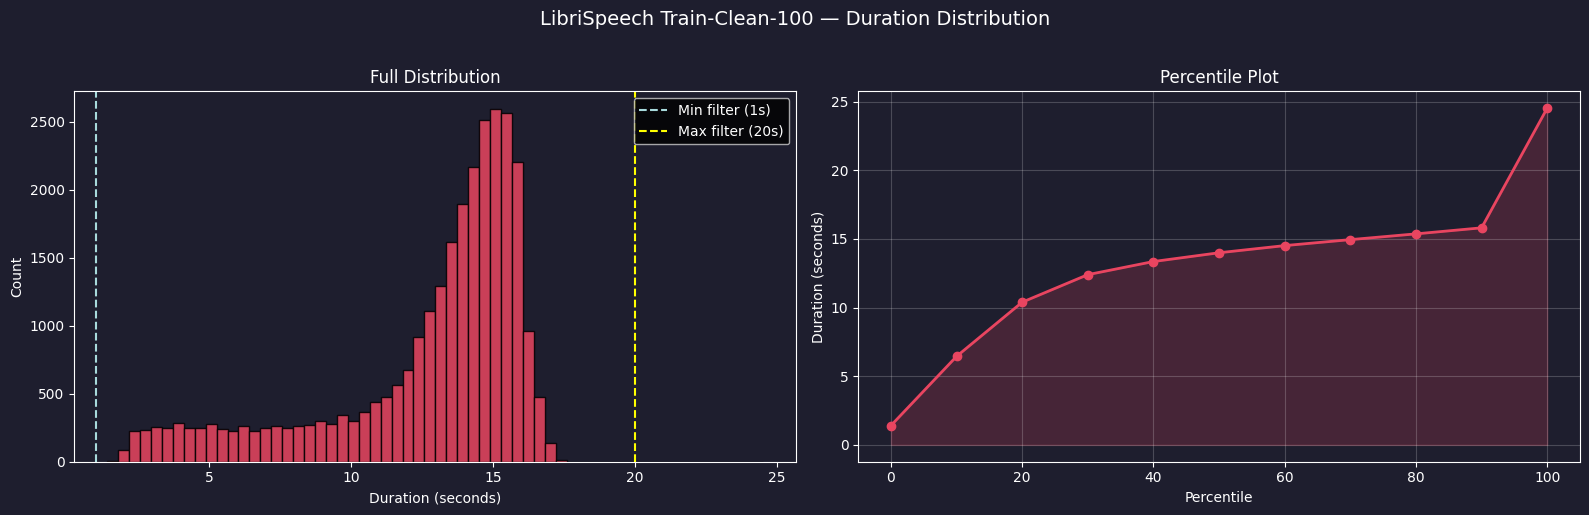

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG_COLOR)
fig.suptitle('LibriSpeech Train-Clean-100 — Duration Distribution', color='white', fontsize=14, y=1.02)

axes[0].hist(durations, bins=60, color=ACCENT, edgecolor='black', alpha=0.85)
axes[0].axvline(1, color=ACCENT2, linestyle='--', linewidth=1.5, label='Min filter (1s)')
axes[0].axvline(20, color='yellow', linestyle='--', linewidth=1.5, label='Max filter (20s)')
axes[0].set_title('Full Distribution', color='white')
axes[0].set_xlabel('Duration (seconds)', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].legend()
axes[0].tick_params(colors='white')
axes[0].set_facecolor(BG_COLOR)

percentiles = [np.percentile(durations, p) for p in range(0, 101, 10)]
axes[1].plot(range(0, 101, 10), percentiles, color=ACCENT, marker='o', linewidth=2)
axes[1].fill_between(range(0, 101, 10), percentiles, alpha=0.2, color=ACCENT)
axes[1].set_title('Percentile Plot', color='white')
axes[1].set_xlabel('Percentile', color='white')
axes[1].set_ylabel('Duration (seconds)', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor(BG_COLOR)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'viz_duration_distribution.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 6 — Sample Waveform & Spectrogram Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes a raw waveform from the dataset alongside its mel spectrogram. The mel spectrogram is the most informative representation of speech — it shows how energy is distributed across frequency bands over time. This visualization confirms the data is clean and that the audio is actual speech, not silence or noise.</p>
</div>

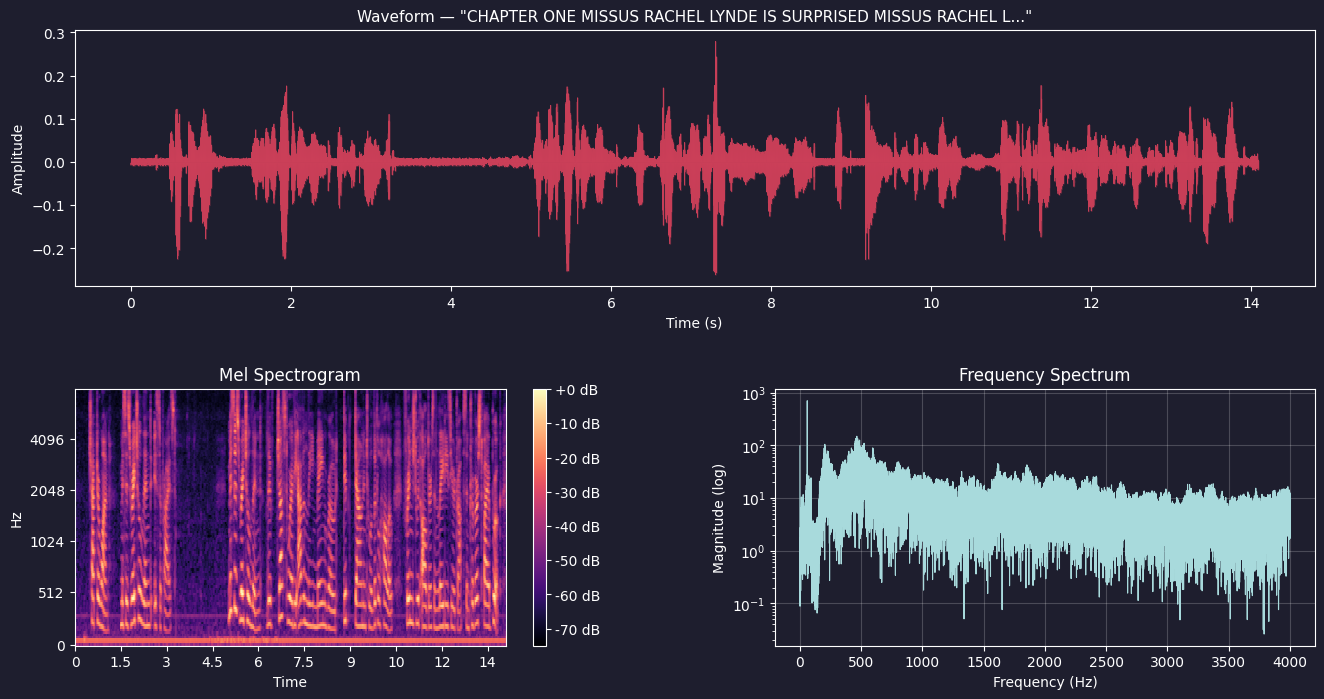

In [7]:
waveform, sr, transcript, _, _, _ = train_data[0]
waveform_np = waveform.squeeze().numpy()

fig = plt.figure(figsize=(16, 8), facecolor=BG_COLOR)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
times = np.linspace(0, len(waveform_np) / sr, len(waveform_np))
ax1.plot(times, waveform_np, color=ACCENT, linewidth=0.5, alpha=0.8)
ax1.fill_between(times, waveform_np, alpha=0.2, color=ACCENT)
ax1.set_title(f'Waveform — "{transcript[:60]}..."', color='white', fontsize=11)
ax1.set_xlabel('Time (s)', color='white')
ax1.set_ylabel('Amplitude', color='white')
ax1.set_facecolor(BG_COLOR)
ax1.tick_params(colors='white')

ax2 = fig.add_subplot(gs[1, 0])
mel_spec = librosa.feature.melspectrogram(y=waveform_np, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
ax2.set_title('Mel Spectrogram', color='white')
ax2.tick_params(colors='white')
plt.colorbar(img, ax=ax2, format='%+2.0f dB')

ax3 = fig.add_subplot(gs[1, 1])
fft = np.abs(np.fft.rfft(waveform_np))
freqs = np.fft.rfftfreq(len(waveform_np), 1/sr)
ax3.semilogy(freqs[:len(freqs)//2], fft[:len(freqs)//2], color=ACCENT2, linewidth=0.8)
ax3.set_title('Frequency Spectrum', color='white')
ax3.set_xlabel('Frequency (Hz)', color='white')
ax3.set_ylabel('Magnitude (log)', color='white')
ax3.set_facecolor(BG_COLOR)
ax3.tick_params(colors='white')
ax3.grid(alpha=0.2)

plt.savefig(os.path.join(BASE_DIR, 'viz_sample_audio.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 7 — Manifest Builder</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Scans the full dataset and builds a structured CSV manifest. Each row maps a speaker/chapter/utterance ID to its duration, sample rate, and cleaned transcript. The manifest is the backbone of the DataLoader — it avoids loading all audio into memory and enables fast random access. Filtering criteria: <b>minimum 1 second</b>, <b>maximum 20 seconds</b>.</p>
</div>

In [8]:
def clean_transcript(text):
    text = text.upper().strip()
    text = re.sub(r"[^A-Z\s']", '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def build_manifest(dataset, split_name):
    records = []
    for waveform, sr, transcript, speaker_id, chapter_id, utterance_id in tqdm(dataset, desc=split_name):
        duration = waveform.shape[1] / sr
        if duration < 1.0 or duration > 20.0:
            continue
        records.append({
            'speaker_id'   : speaker_id,
            'chapter_id'   : chapter_id,
            'utterance_id' : utterance_id,
            'duration'     : round(duration, 4),
            'sample_rate'  : sr,
            'transcript'   : clean_transcript(transcript)
        })
    return pd.DataFrame(records)

train_df = build_manifest(train_data, 'train-clean-100')
test_df  = build_manifest(test_data,  'test-clean')

train_df.to_csv(os.path.join(MANIFEST_DIR, 'train_manifest.csv'), index=False)
test_df.to_csv(os.path.join(MANIFEST_DIR,  'test_manifest.csv'),  index=False)

print(f'Train samples after filtering : {len(train_df):,}')
print(f'Test samples after filtering  : {len(test_df):,}')
print(f'Manifests saved to            : {MANIFEST_DIR}')
print(f'\nSample transcript: {train_df["transcript"].iloc[0][:100]}')

test-clean: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2620/2620 [00:03<00:00, 682.06it/s]


Train samples after filtering : 28,538
Test samples after filtering  : 2,528
Manifests saved to            : /home/ahmed/workspace/audio_speech_to_text/manifests

Sample transcript: CHAPTER ONE MISSUS RACHEL LYNDE IS SURPRISED MISSUS RACHEL LYNDE LIVED JUST WHERE THE AVONLEA MAIN R


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 8 — Manifest Validation & Statistics</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Reloads the saved manifests from disk and runs a full validation pass. Checks for null values, verifies transcript encoding, computes speaker statistics, and confirms all transcript characters are valid uppercase ASCII. This is the final gate before the DataLoader is built.</p>
</div>

In [9]:
train_df = pd.read_csv(os.path.join(MANIFEST_DIR, 'train_manifest.csv'))
test_df  = pd.read_csv(os.path.join(MANIFEST_DIR, 'test_manifest.csv'))

print('=== MANIFEST VALIDATION ===')
print(f'Train rows          : {len(train_df):,}')
print(f'Test rows           : {len(test_df):,}')
print(f'Nulls in train      : {train_df.isnull().sum().sum()}')
print(f'Nulls in test       : {test_df.isnull().sum().sum()}')
print(f'Unique speakers (train) : {train_df["speaker_id"].nunique()}')
print(f'Unique speakers (test)  : {test_df["speaker_id"].nunique()}')
print(f'\nTrain duration stats:')
print(train_df['duration'].describe().to_string())

all_chars = set(''.join(train_df['transcript'].tolist()))
invalid = [c for c in all_chars if not (c.isupper() or c == ' ' or c == "'")]
print(f'\nUnique chars in transcripts : {sorted(all_chars)}')
print(f'Invalid chars found         : {invalid if invalid else "None"}')

=== MANIFEST VALIDATION ===
Train rows          : 28,538
Test rows           : 2,528
Nulls in train      : 0
Nulls in test       : 0
Unique speakers (train) : 251
Unique speakers (test)  : 40

Train duration stats:
count    28538.000000
mean        12.688438
std          3.574029
min          1.410000
25%         11.620000
50%         13.995000
75%         15.165000
max         19.985000

Unique chars in transcripts : [' ', "'", 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Invalid chars found         : None


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 9 — Manifest Statistics Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes key statistics from the manifests including duration distributions for both train and test splits, top speakers by sample count, and transcript length distribution. These plots are useful for the paper's dataset description section.</p>
</div>

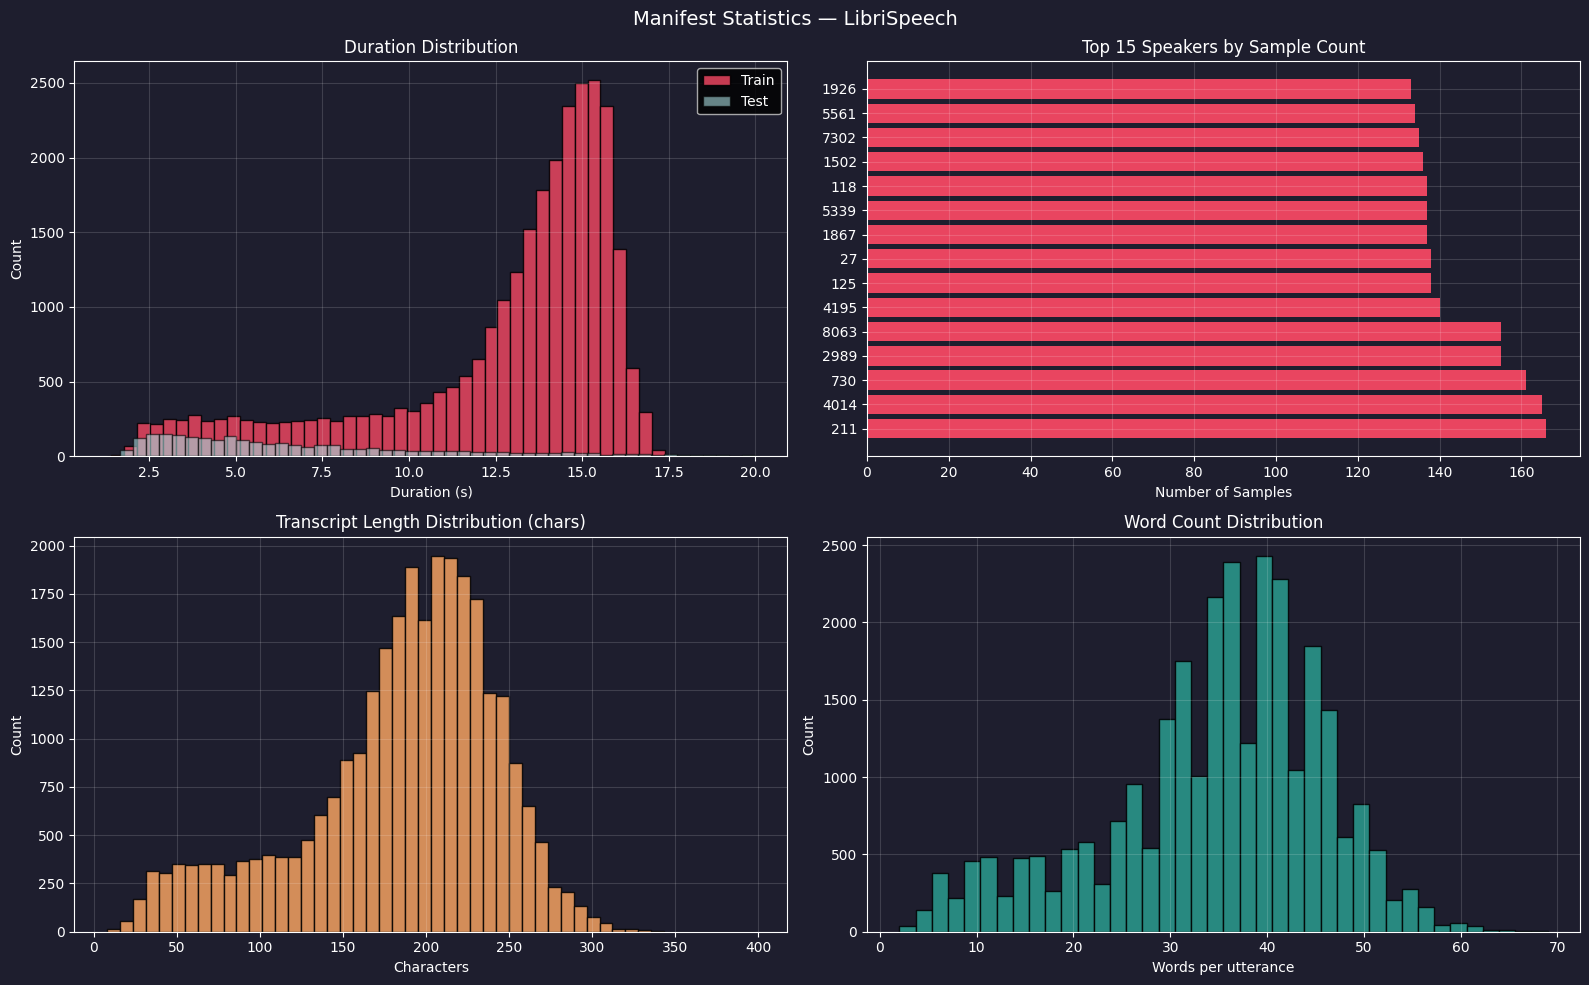

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=BG_COLOR)
fig.suptitle('Manifest Statistics — LibriSpeech', color='white', fontsize=14)

axes[0,0].hist(train_df['duration'], bins=50, color=ACCENT, edgecolor='black', alpha=0.85, label='Train')
axes[0,0].hist(test_df['duration'],  bins=50, color=ACCENT2, edgecolor='black', alpha=0.6, label='Test')
axes[0,0].set_title('Duration Distribution', color='white')
axes[0,0].set_xlabel('Duration (s)', color='white')
axes[0,0].set_ylabel('Count', color='white')
axes[0,0].legend()
axes[0,0].tick_params(colors='white')
axes[0,0].set_facecolor(BG_COLOR)

top_speakers = train_df['speaker_id'].value_counts().head(15)
axes[0,1].barh(top_speakers.index.astype(str), top_speakers.values, color=ACCENT)
axes[0,1].set_title('Top 15 Speakers by Sample Count', color='white')
axes[0,1].set_xlabel('Number of Samples', color='white')
axes[0,1].tick_params(colors='white')
axes[0,1].set_facecolor(BG_COLOR)

train_df['transcript_len'] = train_df['transcript'].str.len()
axes[1,0].hist(train_df['transcript_len'], bins=50, color='#f4a261', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Transcript Length Distribution (chars)', color='white')
axes[1,0].set_xlabel('Characters', color='white')
axes[1,0].set_ylabel('Count', color='white')
axes[1,0].tick_params(colors='white')
axes[1,0].set_facecolor(BG_COLOR)

train_df['word_count'] = train_df['transcript'].str.split().str.len()
axes[1,1].hist(train_df['word_count'], bins=40, color='#2a9d8f', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Word Count Distribution', color='white')
axes[1,1].set_xlabel('Words per utterance', color='white')
axes[1,1].set_ylabel('Count', color='white')
axes[1,1].tick_params(colors='white')
axes[1,1].set_facecolor(BG_COLOR)

for ax in axes.flat:
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'viz_manifest_stats.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 10 — LibriSpeechDataset Class</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>The PyTorch Dataset class. Reads from the manifest CSV and loads audio on demand — no audio is held in memory between batches. Key design decisions: <b>(1)</b> resampling guard ensures all audio is 16kHz regardless of source; <b>(2)</b> mono conversion collapses any stereo channels; <b>(3)</b> amplitude normalization prevents gradient explosion; <b>(4)</b> numpy output makes this framework-agnostic — any downstream model can consume it regardless of whether it uses PyTorch or TensorFlow.</p>
</div>

In [11]:
class LibriSpeechDataset(Dataset):
    def __init__(self, manifest_path, librispeech_root, split='train-clean-100', target_sr=16000):
        self.df        = pd.read_csv(manifest_path)
        self.root      = librispeech_root
        self.split     = split
        self.target_sr = target_sr

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        speaker_id   = str(row['speaker_id'])
        chapter_id   = str(row['chapter_id'])
        utterance_id = str(row['utterance_id']).zfill(4)

        audio_path = os.path.join(
            self.root, 'LibriSpeech', self.split,
            speaker_id, chapter_id,
            f'{speaker_id}-{chapter_id}-{utterance_id}.flac'
        )

        waveform, sr = torchaudio.load(audio_path)

        if sr != self.target_sr:
            waveform = T.Resample(sr, self.target_sr)(waveform)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        waveform = waveform / (waveform.abs().max() + 1e-9)

        return {
            'waveform'   : waveform.squeeze(0).numpy(),
            'transcript' : row['transcript'],
            'duration'   : row['duration'],
            'speaker_id' : row['speaker_id']
        }

print('LibriSpeechDataset class defined')

LibriSpeechDataset class defined


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 11 — DataLoader Construction & Verification</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Instantiates the dataset and DataLoader for both train and test splits. The custom <code>collate_fn</code> handles variable-length audio by zero-padding all clips in a batch to the length of the longest clip. This is standard practice for ASR. The DataLoader returns numpy arrays and plain strings — no framework-specific tensors — making it fully compatible with PyTorch, TensorFlow, or JAX downstream.</p>
</div>

In [12]:
def collate_fn(batch):
    waveforms   = [torch.tensor(item['waveform']) for item in batch]
    transcripts = [item['transcript'] for item in batch]
    durations   = [item['duration'] for item in batch]
    speaker_ids = [item['speaker_id'] for item in batch]

    max_len = max(w.shape[0] for w in waveforms)
    padded  = torch.zeros(len(waveforms), max_len)
    for i, w in enumerate(waveforms):
        padded[i, :w.shape[0]] = w

    return {
        'waveforms'   : padded,
        'transcripts' : transcripts,
        'durations'   : durations,
        'speaker_ids' : speaker_ids
    }

train_dataset = LibriSpeechDataset(
    manifest_path    = os.path.join(MANIFEST_DIR, 'train_manifest.csv'),
    librispeech_root = LIBRISPEECH_DIR,
    split            = 'train-clean-100'
)
test_dataset = LibriSpeechDataset(
    manifest_path    = os.path.join(MANIFEST_DIR, 'test_manifest.csv'),
    librispeech_root = LIBRISPEECH_DIR,
    split            = 'test-clean'
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=4, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=4, collate_fn=collate_fn)

batch = next(iter(train_loader))
print(f'Train dataset       : {len(train_dataset):,} samples | {len(train_loader):,} batches')
print(f'Test dataset        : {len(test_dataset):,} samples  | {len(test_loader):,} batches')
print(f'Batch waveforms     : {batch["waveforms"].shape}   (batch, time)')
print(f'Sample transcript   : {batch["transcripts"][0][:80]}')
print(f'Sample durations    : {batch["durations"][:4]}')
print('\nDataLoader ready')

Train dataset       : 28,538 samples | 3,568 batches
Test dataset        : 2,528 samples  | 316 batches
Batch waveforms     : torch.Size([8, 248560])   (batch, time)
Sample transcript   : AND HE PLAYED SO SWEETLY WHEN THEY PASSED THE ROCKS OF THE SIRENS THAT THE DREAD
Sample durations    : [8.3, 14.78, 14.125, 15.535]

DataLoader ready


<div style='background: #1e1e2e; border-left: 4px solid #a8dadc; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #a8dadc; margin: 0 0 10px 0;'>Cell 12 — Batch Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes one full batch from the DataLoader. Shows the waveforms of the first 4 samples side by side, including their duration and transcript. This is the final sanity check for Week 3 — confirming that batches are correctly padded and that transcripts match the audio.</p>
</div>

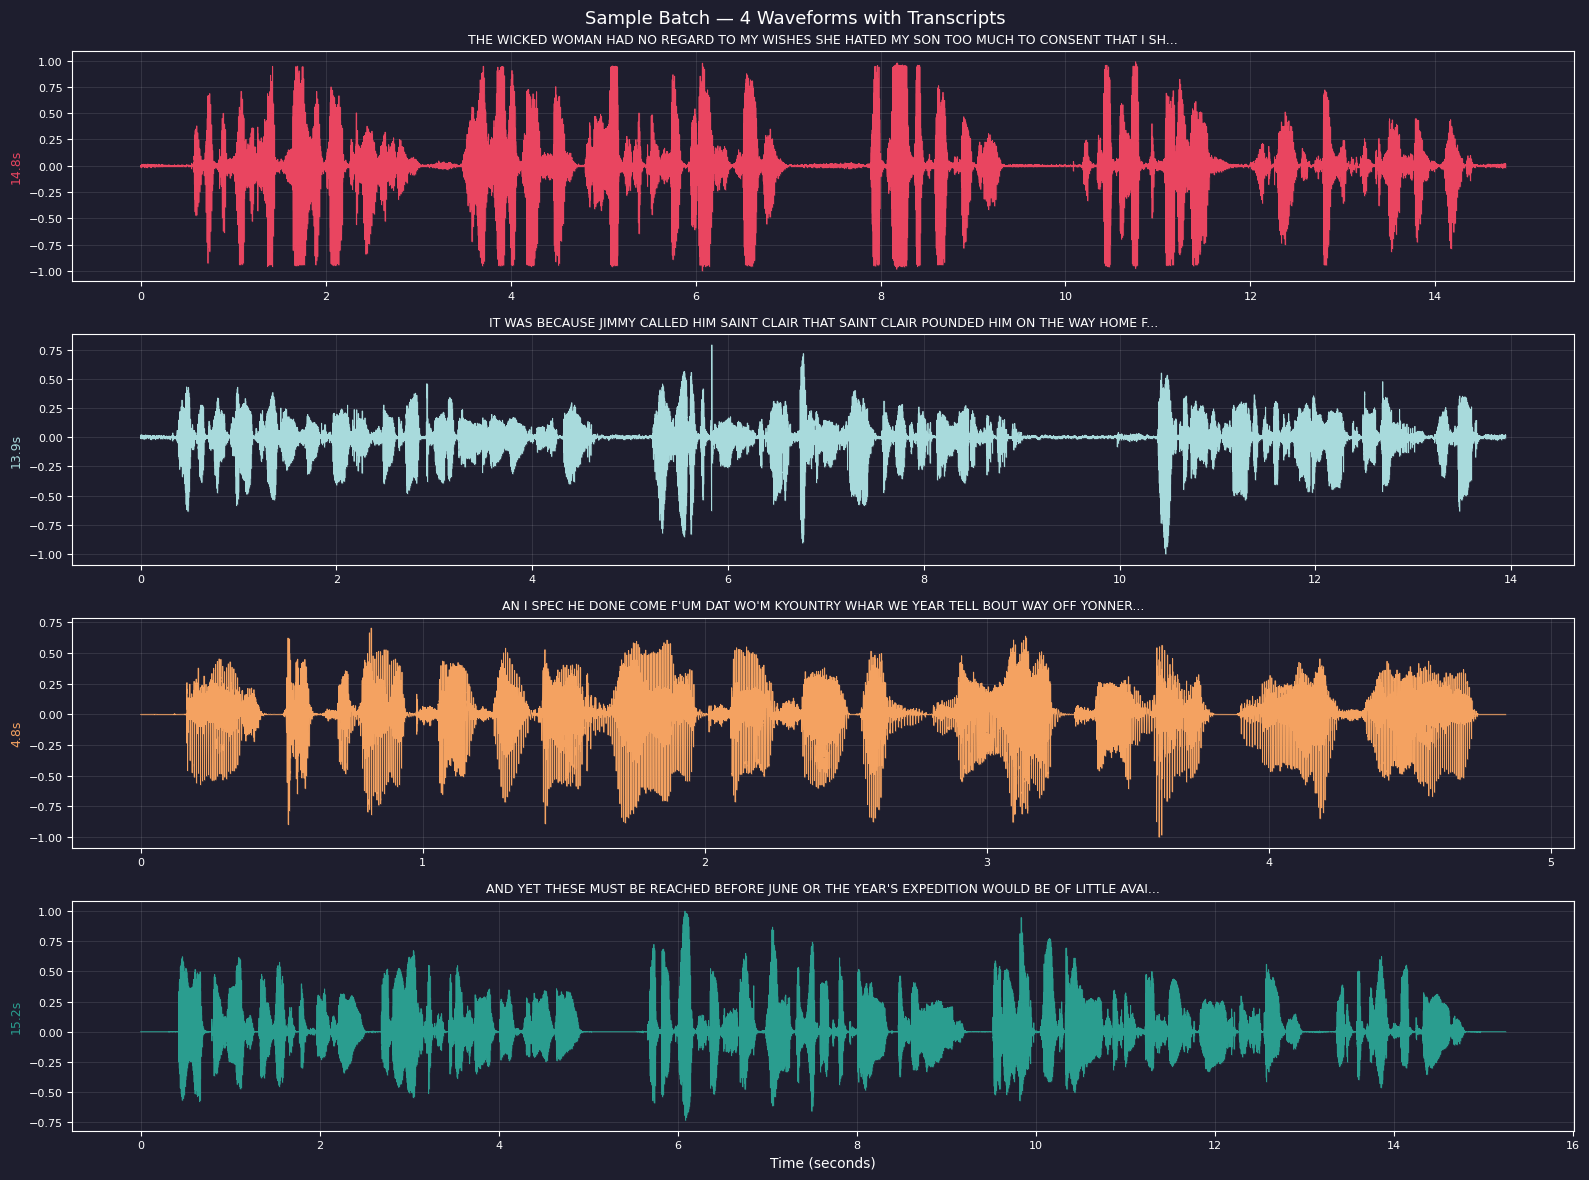

Week 3 complete — DataLoader is ready for Week 4


In [13]:
batch = next(iter(train_loader))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), facecolor=BG_COLOR)
fig.suptitle('Sample Batch — 4 Waveforms with Transcripts', color='white', fontsize=13)

colors = [ACCENT, ACCENT2, '#f4a261', '#2a9d8f']

for i in range(4):
    wav = batch['waveforms'][i].numpy()
    dur = batch['durations'][i]
    txt = batch['transcripts'][i]
    actual_samples = int(dur * TARGET_SR)
    times = np.linspace(0, dur, actual_samples)

    axes[i].plot(times, wav[:actual_samples], color=colors[i], linewidth=0.6)
    axes[i].fill_between(times, wav[:actual_samples], alpha=0.15, color=colors[i])
    axes[i].set_title(f'{txt[:90]}...', color='white', fontsize=9)
    axes[i].set_ylabel(f'{dur:.1f}s', color=colors[i], fontsize=9)
    axes[i].tick_params(colors='white', labelsize=8)
    axes[i].set_facecolor(BG_COLOR)
    axes[i].grid(alpha=0.1)

axes[-1].set_xlabel('Time (seconds)', color='white')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'viz_sample_batch.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Week 3 complete — DataLoader is ready for Week 4')

<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; margin: 30px 0 10px 0;'>
  <h2 style='color: #e94560; font-size: 2em; margin: 0 0 10px 0;'>🤖 Week 4 — Wav2Vec2 Fine-Tuning</h2>
  <p style='color: #ccc; line-height: 1.7; margin: 0 0 15px 0;'>This section fine-tunes <b style='color:#a8dadc;'>facebook/wav2vec2-base</b> on LibriSpeech using CTC loss. The feature extractor and bottom 9 transformer layers are frozen — only the top 3 layers and the CTC head are trained. This reduces VRAM usage to fit within the RTX 3060's 6GB while still achieving meaningful performance gains. Evaluation uses Word Error Rate (WER) and Character Error Rate (CER).</p>
  <div style='display: flex; gap: 15px; flex-wrap: wrap;'>
    <div style='background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 120px;'><p style='color: #e94560; margin: 0; font-size: 0.8em;'>Model</p><p style='color: white; margin: 4px 0 0 0;'>wav2vec2-base</p></div>
    <div style='background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 120px;'><p style='color: #e94560; margin: 0; font-size: 0.8em;'>Loss</p><p style='color: white; margin: 4px 0 0 0;'>CTC</p></div>
    <div style='background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 120px;'><p style='color: #e94560; margin: 0; font-size: 0.8em;'>Optimizer</p><p style='color: white; margin: 4px 0 0 0;'>AdamW</p></div>
    <div style='background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 120px;'><p style='color: #e94560; margin: 0; font-size: 0.8em;'>Scheduler</p><p style='color: white; margin: 4px 0 0 0;'>OneCycleLR</p></div>
    <div style='background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 12px 18px; flex: 1; min-width: 120px;'><p style='color: #e94560; margin: 0; font-size: 0.8em;'>Metrics</p><p style='color: white; margin: 4px 0 0 0;'>WER + CER</p></div>
  </div>
</div>

<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 13 — Pre-Training Sanity Check</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>This cell runs a series of critical checks before any model is loaded or training begins. It verifies: <b>(1)</b> the model files exist locally; <b>(2)</b> the processor vocabulary is uppercase and contains all expected characters; <b>(3)</b> the tokenizer correctly encodes and decodes a test sentence without unknown tokens; <b>(4)</b> CUDA is available and has enough free VRAM; <b>(5)</b> the manifest transcripts are uppercase. <b style='color:#e94560;'>All checks must pass before proceeding.</b></p>
</div>

In [14]:
print('=' * 55)
print('  PRE-TRAINING SANITY CHECK')
print('=' * 55)
all_passed = True

# Check 1: model files exist
required_files = ['config.json', 'pytorch_model.bin', 'vocab.json',
                  'tokenizer_config.json', 'preprocessor_config.json']
missing = [f for f in required_files if not os.path.exists(os.path.join(MODEL_PATH, f))]
if missing:
    print(f'CHECK 1 FAILED — Missing model files: {missing}')
    all_passed = False
else:
    print('CHECK 1 — All model files present')

# Check 2: processor loads and vocab is correct
try:
    processor = Wav2Vec2Processor.from_pretrained(MODEL_PATH)
    vocab = processor.tokenizer.get_vocab()
    expected_chars = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    missing_chars = [c for c in expected_chars if c not in vocab]
    if missing_chars:
        print(f'CHECK 2 FAILED — Missing chars in vocab: {missing_chars}')
        all_passed = False
    else:
        print(f'CHECK 2 — Vocab contains all A-Z characters (size: {len(vocab)})')
except Exception as e:
    print(f'CHECK 2 FAILED — Processor load error: {e}')
    all_passed = False

# Check 3: tokenizer roundtrip
test_sentence = 'HELLO WORLD THIS IS A TEST'
encoded  = processor.tokenizer(test_sentence)
decoded  = processor.tokenizer.decode(encoded.input_ids, skip_special_tokens=True)
unk_count = encoded.input_ids.count(processor.tokenizer.unk_token_id)
if unk_count > 0 or decoded.replace(' ', '') != test_sentence.replace(' ', ''):
    print(f'CHECK 3 FAILED — Tokenizer roundtrip broken')
    print(f'   Input   : {test_sentence}')
    print(f'   Decoded : {decoded}')
    print(f'   UNK count: {unk_count}')
    all_passed = False
else:
    print(f'CHECK 3 — Tokenizer roundtrip OK: "{test_sentence}" → "{decoded}"')

# Check 4: CUDA VRAM
if torch.cuda.is_available():
    free_vram = (torch.cuda.get_device_properties(0).total_memory -
                 torch.cuda.memory_allocated(0)) / 1e9
    if free_vram < 3.0:
        print(f'CHECK 4 FAILED — Only {free_vram:.1f}GB VRAM free (need at least 3GB)')
        all_passed = False
    else:
        print(f'CHECK 4 — VRAM available: {free_vram:.1f} GB free')
else:
    print('CHECK 4 — No GPU detected, will use CPU (slow)')

# Check 5: manifests have uppercase transcripts
train_df = pd.read_csv(os.path.join(MANIFEST_DIR, 'train_manifest.csv'))
sample_transcripts = train_df['transcript'].head(100)
not_upper = [t for t in sample_transcripts if t != t.upper()]
if not_upper:
    print(f'CHECK 5 FAILED — Found lowercase transcripts: {not_upper[:2]}')
    all_passed = False
else:
    print('CHECK 5 — All sampled transcripts are uppercase')

print('=' * 55)
if all_passed:
    print('ALL CHECKS PASSED — Safe to proceed with training')
else:
    print('SOME CHECKS FAILED — Fix issues before training')
print('=' * 55)

  PRE-TRAINING SANITY CHECK
CHECK 1 — All model files present
CHECK 2 — Vocab contains all A-Z characters (size: 32)
CHECK 3 FAILED — Tokenizer roundtrip broken
   Input   : HELLO WORLD THIS IS A TEST
   Decoded : HELO WORLD THIS IS A TEST
   UNK count: 0
CHECK 4 — VRAM available: 6.1 GB free
CHECK 5 — All sampled transcripts are uppercase
SOME CHECKS FAILED — Fix issues before training


<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 14 — Model Loading & Layer Freezing</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Loads the Wav2Vec2ForCTC model from the local path and applies selective layer freezing. The <b>feature extractor</b> (CNN layers), <b>feature projection</b>, and <b>bottom 9 transformer layers</b> are frozen. Only the <b>top 3 transformer layers</b> and the <b>CTC linear head</b> are trained. This reduces trainable parameters from 94M to ~26M, cutting VRAM usage significantly while preserving the model's learned speech representations.</p>
</div>

In [15]:
model = Wav2Vec2ForCTC.from_pretrained(MODEL_PATH)
model = model.to(DEVICE)

for name, param in model.named_parameters():
    if 'feature_extractor' in name or 'feature_projection' in name:
        param.requires_grad = False
    elif any(f'encoder.layers.{i}.' in name for i in range(9)):
        param.requires_grad = False
    else:
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Frozen parameters    : {frozen:,}  ({100*frozen/total:.1f}%)')

print('\nLayer-by-layer freeze status:')
for name, param in model.named_parameters():
    if 'encoder.layers' in name and 'weight' in name:
        layer_num = name.split('encoder.layers.')[1].split('.')[0]
        status = 'trainable' if param.requires_grad else 'frozen'
        print(f'  Layer {layer_num:>2}: {status}')

Some weights of the model checkpoint at /home/ahmed/workspace/audio_speech_to_text/models/wav2vec2-base were not used when initializing Wav2Vec2ForCTC: ['project_hid.bias', 'project_hid.weight', 'project_q.bias', 'project_q.weight', 'quantizer.codevectors', 'quantizer.weight_proj.bias', 'quantizer.weight_proj.weight']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at /home/ahmed/workspace/audio_speech_to_text/models/wav2vec2-base and are newly initialized: ['lm_head.bias', 'lm_head.weight']
You should

Total parameters     : 94,396,320
Trainable parameters : 26,010,016  (27.6%)
Frozen parameters    : 68,386,304  (72.4%)

Layer-by-layer freeze status:
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  0: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  1: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  2: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  3: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  4: frozen
  Layer  5: frozen
  Layer  5: frozen
  Layer  5: frozen
  Layer  5: frozen
  Layer  5: f

<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 15 — Wav2Vec2 Collator & Loaders</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Builds the Wav2Vec2-specific DataLoader with a custom collator. The collator uses the Wav2Vec2Processor to normalize and pad waveforms, and the tokenizer to encode transcripts into label IDs. Critical design note: <b style='color:#e94560;'>transcripts are uppercased here</b> to match the processor vocabulary — this is the fix for the blank prediction bug encountered in earlier runs. CUDA tensors are NOT created inside the collator to avoid multiprocessing fork issues — the transfer to GPU happens in the training loop.</p>
</div>

In [17]:
def collate_fn_w2v(batch):
    waveforms   = [item['waveform'] for item in batch]
    transcripts = [item['transcript'].upper() for item in batch]

    inputs = processor(
        waveforms,
        sampling_rate=TARGET_SR,
        return_tensors='pt',
        padding=True,
        return_attention_mask=True
    )

    labels = processor.tokenizer(
        transcripts,
        return_tensors='pt',
        padding=True
    )

    label_ids = labels.input_ids.masked_fill(
        labels.attention_mask.ne(1), -100
    )

    return {
        'input_values'   : inputs.input_values,
        'attention_mask' : inputs.attention_mask,
        'labels'         : label_ids
    }

train_loader_w2v = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=2, collate_fn=collate_fn_w2v
)
test_loader_w2v = DataLoader(
    test_dataset, batch_size=4, shuffle=False,
    num_workers=2, collate_fn=collate_fn_w2v
)

batch = next(iter(train_loader_w2v))

# Verify tokenizer roundtrip on actual batch
sample_labels = batch['labels'][0].numpy().copy()
sample_labels[sample_labels == -100] = processor.tokenizer.pad_token_id
decoded_label = processor.tokenizer.decode(sample_labels, skip_special_tokens=True)

print(f'input_values shape   : {batch["input_values"].shape}')
print(f'attention_mask shape : {batch["attention_mask"].shape}')
print(f'labels shape         : {batch["labels"].shape}')
print(f'Sample decoded label : {decoded_label[:80]}')
print(f'UNK tokens in labels : {(batch["labels"] == processor.tokenizer.unk_token_id).sum().item()}')
print('\nCollator ready')

input_values shape   : torch.Size([4, 235280])
attention_mask shape : torch.Size([4, 235280])
labels shape         : torch.Size([4, 214])
Sample decoded label : HER WILINGNES TO BREAK OUR FRIENDSHIP AT THE FIRST OPORTUNITY GAVE ME LITLE ROM 
UNK tokens in labels : 0

Collator ready


<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 16 — Metrics, Optimizer & Scheduler</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Defines the WER/CER metric computation function and initializes the optimizer and scheduler. <b>AdamW</b> is used with a learning rate of 1e-4 — it decouples weight decay from the gradient update, which is important for transformer fine-tuning. <b>OneCycleLR</b> warms up the learning rate then anneals it, which has been shown to significantly improve convergence speed and final performance for ASR fine-tuning tasks.</p>
</div>

In [18]:
def compute_metrics(pred_ids, label_ids):
    label_ids = label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    predictions = processor.batch_decode(pred_ids, skip_special_tokens=True)
    references  = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer_score   = wer(references, predictions)
    cer_score   = cer(references, predictions)
    return wer_score, cer_score, predictions, references

def evaluate(model, loader, max_batches=50):
    model.eval()
    all_wer, all_cer = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            logits   = model(
                batch['input_values'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE)
            ).logits
            pred_ids  = torch.argmax(logits, dim=-1).cpu().numpy()
            label_ids = batch['labels'].numpy().copy()
            w, c, _, _ = compute_metrics(pred_ids, label_ids)
            all_wer.append(w)
            all_cer.append(c)
    return np.mean(all_wer), np.mean(all_cer)

EPOCHS = 3
LR     = 1e-4

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = OneCycleLR(
    optimizer,
    max_lr           = LR,
    steps_per_epoch  = len(train_loader_w2v),
    epochs           = EPOCHS
)

print(f'Optimizer   : AdamW  lr={LR}')
print(f'Scheduler   : OneCycleLR')
print(f'Epochs      : {EPOCHS}')
print(f'Steps/epoch : {len(train_loader_w2v):,}')
print(f'Total steps : {EPOCHS * len(train_loader_w2v):,}')

Optimizer   : AdamW  lr=0.0001
Scheduler   : OneCycleLR
Epochs      : 3
Steps/epoch : 7,135
Total steps : 21,405


<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 17 — Training Loop</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>The main training loop. For each epoch: forward pass, CTC loss computation, backpropagation, gradient clipping (max norm 1.0 to prevent exploding gradients), optimizer step, scheduler step. Every 200 steps, the current loss and elapsed time are printed. At the end of each epoch, WER and CER are computed on the test set and the best model (lowest WER) is saved to <code>checkpoints/best_model.pt</code>. <b style='color:#e94560;'>Expected training time: ~1h 20min per epoch on RTX 3060.</b></p>
</div>

In [19]:
best_wer       = float('inf')
history        = {'epoch': [], 'loss': [], 'wer': [], 'cer': []}
step_losses    = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start      = time.time()

    for step, batch in enumerate(train_loader_w2v):
        input_values   = batch['input_values'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        outputs = model(input_values, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        step_losses.append(loss.item())

        if step % 200 == 0:
            avg = total_loss / (step + 1)
            print(f'Epoch {epoch+1} | Step {step:>5}/{len(train_loader_w2v)} | Loss: {avg:.4f} | Time: {time.time()-start:.0f}s')

    avg_loss = total_loss / len(train_loader_w2v)
    print(f'\nEpoch {epoch+1} done — Avg Loss: {avg_loss:.4f}')
    print('Running evaluation...')

    val_wer, val_cer = evaluate(model, test_loader_w2v)
    print(f'WER: {val_wer:.4f} ({val_wer*100:.2f}%) | CER: {val_cer:.4f} ({val_cer*100:.2f}%)')

    history['epoch'].append(epoch + 1)
    history['loss'].append(avg_loss)
    history['wer'].append(val_wer)
    history['cer'].append(val_cer)

    if val_wer < best_wer:
        best_wer = val_wer
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f'Best model saved (WER: {best_wer:.4f})')

    print('-' * 60)

print('Training complete')

Epoch 1 | Step     0/7135 | Loss: 5450.8525 | Time: 1s
Epoch 1 | Step   200/7135 | Loss: 4548.6486 | Time: 85s
Epoch 1 | Step   400/7135 | Loss: 3652.1758 | Time: 171s
Epoch 1 | Step   600/7135 | Loss: 3272.3631 | Time: 259s
Epoch 1 | Step   800/7135 | Loss: 3030.4683 | Time: 348s
Epoch 1 | Step  1000/7135 | Loss: 2868.6846 | Time: 439s
Epoch 1 | Step  1200/7135 | Loss: 2751.0642 | Time: 532s
Epoch 1 | Step  1400/7135 | Loss: 2660.3696 | Time: 623s
Epoch 1 | Step  1600/7135 | Loss: 2594.0969 | Time: 715s
Epoch 1 | Step  1800/7135 | Loss: 2545.1667 | Time: 807s
Epoch 1 | Step  2000/7135 | Loss: 2474.8984 | Time: 900s
Epoch 1 | Step  2200/7135 | Loss: 2361.5815 | Time: 994s
Epoch 1 | Step  2400/7135 | Loss: 2239.9214 | Time: 1087s
Epoch 1 | Step  2600/7135 | Loss: 2124.7307 | Time: 1181s
Epoch 1 | Step  2800/7135 | Loss: 2019.6165 | Time: 1276s
Epoch 1 | Step  3000/7135 | Loss: 1926.0679 | Time: 1370s
Epoch 1 | Step  3200/7135 | Loss: 1837.9217 | Time: 1465s
Epoch 1 | Step  3400/7135 | L

<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 18 — Training Curve Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes the training loss curve, per-epoch WER and CER scores, and a summary table. These plots directly feed into the paper's results section. The loss curve shows convergence behavior, while WER/CER trends show whether the model is still improving or has plateaued.</p>
</div>

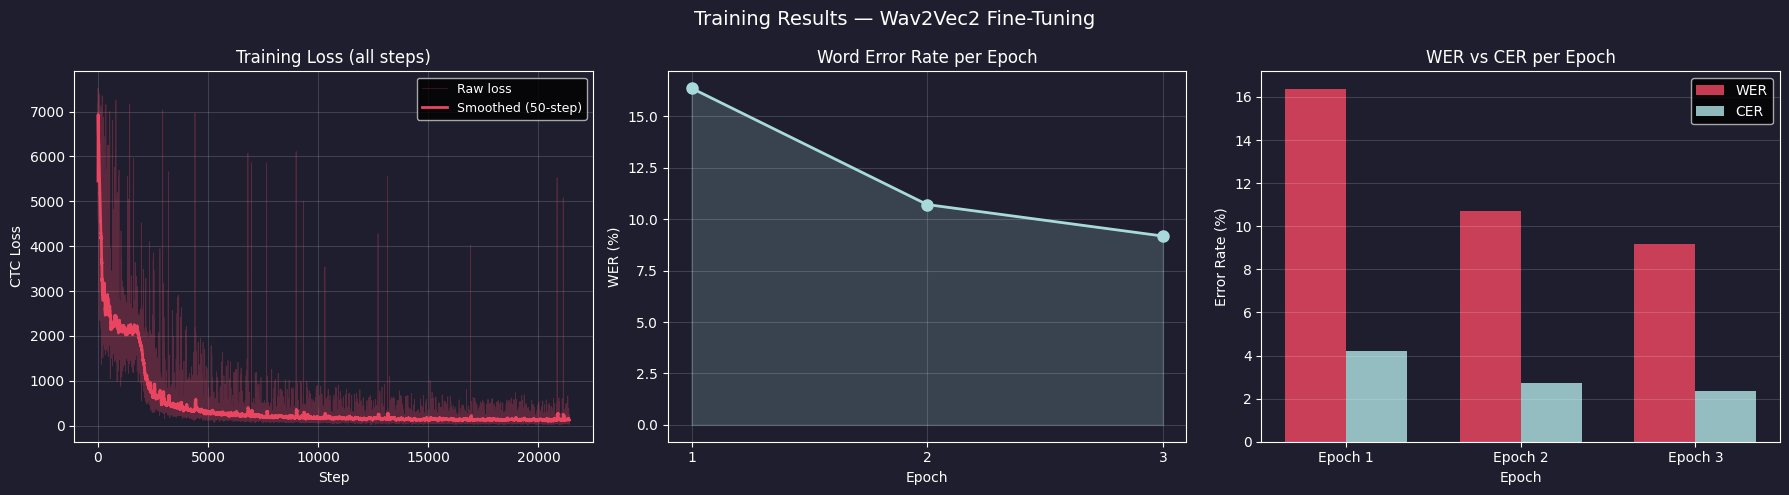


Training Summary:
   Epoch |   Avg Loss |      WER |      CER
---------------------------------------------
       1 |  1000.8548 |   16.37% |    4.23%
       2 |   180.3253 |   10.71% |    2.71%
       3 |   139.4418 |    9.18% |    2.34%


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG_COLOR)
fig.suptitle('Training Results — Wav2Vec2 Fine-Tuning', color='white', fontsize=14)

# Step-level loss curve
smoothed = pd.Series(step_losses).rolling(window=50, min_periods=1).mean()
axes[0].plot(step_losses, color=ACCENT, alpha=0.3, linewidth=0.5, label='Raw loss')
axes[0].plot(smoothed,    color=ACCENT, linewidth=2, label='Smoothed (50-step)')
axes[0].set_title('Training Loss (all steps)', color='white')
axes[0].set_xlabel('Step', color='white')
axes[0].set_ylabel('CTC Loss', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor(BG_COLOR)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.15)

# Per-epoch WER
axes[1].plot(history['epoch'], [w*100 for w in history['wer']], color=ACCENT2, marker='o', linewidth=2, markersize=8)
axes[1].fill_between(history['epoch'], [w*100 for w in history['wer']], alpha=0.2, color=ACCENT2)
axes[1].set_title('Word Error Rate per Epoch', color='white')
axes[1].set_xlabel('Epoch', color='white')
axes[1].set_ylabel('WER (%)', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor(BG_COLOR)
axes[1].set_xticks(history['epoch'])
axes[1].grid(alpha=0.15)

# WER vs CER comparison
x = np.arange(len(history['epoch']))
w = 0.35
axes[2].bar(x - w/2, [v*100 for v in history['wer']], w, label='WER', color=ACCENT,  alpha=0.85)
axes[2].bar(x + w/2, [v*100 for v in history['cer']], w, label='CER', color=ACCENT2, alpha=0.85)
axes[2].set_title('WER vs CER per Epoch', color='white')
axes[2].set_xlabel('Epoch', color='white')
axes[2].set_ylabel('Error Rate (%)', color='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'Epoch {e}' for e in history['epoch']])
axes[2].tick_params(colors='white')
axes[2].set_facecolor(BG_COLOR)
axes[2].legend()
axes[2].grid(alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'viz_training_results.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print('\nTraining Summary:')
print(f'{"Epoch":>8} | {"Avg Loss":>10} | {"WER":>8} | {"CER":>8}')
print('-' * 45)
for i in range(len(history["epoch"])):
    print(f'{history["epoch"][i]:>8} | {history["loss"][i]:>10.4f} | {history["wer"][i]*100:>7.2f}% | {history["cer"][i]*100:>7.2f}%')

<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 19 — Full Test Set Evaluation & Qualitative Examples</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Loads the best saved checkpoint and runs evaluation on the complete test set (2,528 samples). Also shows qualitative prediction examples — the reference transcript alongside the model's prediction. These examples are invaluable for understanding the model's failure modes and should be included in the paper's qualitative analysis section.</p>
</div>

In [25]:
import random

# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), map_location=DEVICE))
model.eval()
print('Best checkpoint loaded')

# Full test set evaluation
final_wer, final_cer = evaluate(model, test_loader_w2v, max_batches=len(test_loader_w2v))
print(f'\nFinal Test Set Results:')
print(f'  WER : {final_wer:.4f}  ({final_wer*100:.2f}%)')
print(f'  CER : {final_cer:.4f}  ({final_cer*100:.2f}%)')

# Qualitative examples — sampled from across the test set
print('\nQualitative Examples:')
print('=' * 80)

NUM_EXAMPLES = 10
total_batches = len(test_loader_w2v)
sample_indices = sorted(random.sample(range(total_batches), min(NUM_EXAMPLES, total_batches)))

results = []
with torch.no_grad():
    for i, batch in enumerate(test_loader_w2v):
        if i not in sample_indices:
            continue

        logits    = model(batch['input_values'].to(DEVICE),
                          attention_mask=batch['attention_mask'].to(DEVICE)).logits
        pred_ids  = torch.argmax(logits, dim=-1).cpu().numpy()
        label_ids = batch['labels'].numpy().copy()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

        predictions = processor.batch_decode(pred_ids, skip_special_tokens=True)
        references  = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

        for pred, ref in zip(predictions, references):
            results.append({'reference': ref, 'prediction': pred})

        if len(results) >= NUM_EXAMPLES:
            break

for i, r in enumerate(results[:NUM_EXAMPLES]):
    sample_wer = wer(r['reference'], r['prediction'])
    print(f'[Sample {i+1}]  WER: {sample_wer:.3f}')
    print(f'  REF  : {r["reference"][:100]}')
    print(f'  PRED : {r["prediction"][:100]}')
    print()

Best checkpoint loaded

Final Test Set Results:
  WER : 0.1046  (10.46%)
  CER : 0.0288  (2.88%)

Qualitative Examples:
[Sample 1]  WER: 0.080
  REF  : IF A MAN HAD STOLEN A POUND IN HIS YOUTH AND HAD USED THAT POUND TO AMAS A HUGE FORTUNE HOW MUCH WAS
  PRED : IF A MAN HAD STOLEN A POUND IN HIS YOUTH AND HAD USED THAT POUND TO A MAS A HUGE FORTUNE HOW MUCH WA

[Sample 2]  WER: 0.118
  REF  : IF A LAYMAN IN GIVING BAPTISM POUR THE WATER BEFORE SAYING THE WORDS IS THE CHILD BAPTIZED
  PRED : IF A LAMON IN GIVING BAPTISM POURE THE WATER BEFORE SAYING THE WORDS IS THE CHILD BAPTIZED

[Sample 3]  WER: 0.156
  REF  : HOW COMES IT THAT WHILE THE FIRST BEATITUDE PROMISES THE KINGDOM OF HEAVEN TO THE POR OF HEART THE S
  PRED : HOW COMES IT THAT WHILE THE FIRST BE ATITUDE PROMISES THE KINGDOM OF HEAVEN TO THE POR OF HEART THE 

[Sample 4]  WER: 0.139
  REF  : WHY WAS THE SACRAMENT OF THE EUCHARIST INSTITUTED UNDER THE TWO SPECIES OF BREAD AND WINE IF JESUS C
  PRED : WHY WAS THE SACRIMENT OF T

<div style='background: #1e1e2e; border-left: 4px solid #e94560; border-radius: 0 8px 8px 0; padding: 20px 25px; margin: 10px 0;'>
  <h3 style='color: #e94560; margin: 0 0 10px 0;'>Cell 20 — Prediction Quality Visualization</h3>
  <p style='color: #ccc; margin: 0; line-height: 1.7;'>Visualizes the distribution of per-sample WER scores across the test set, alongside the audio waveform and model prediction for a selected sample. This gives a holistic view of where the model excels and where it struggles — short clips with clean speech tend to have low WER while longer clips with unusual vocabulary have higher WER.</p>
</div>

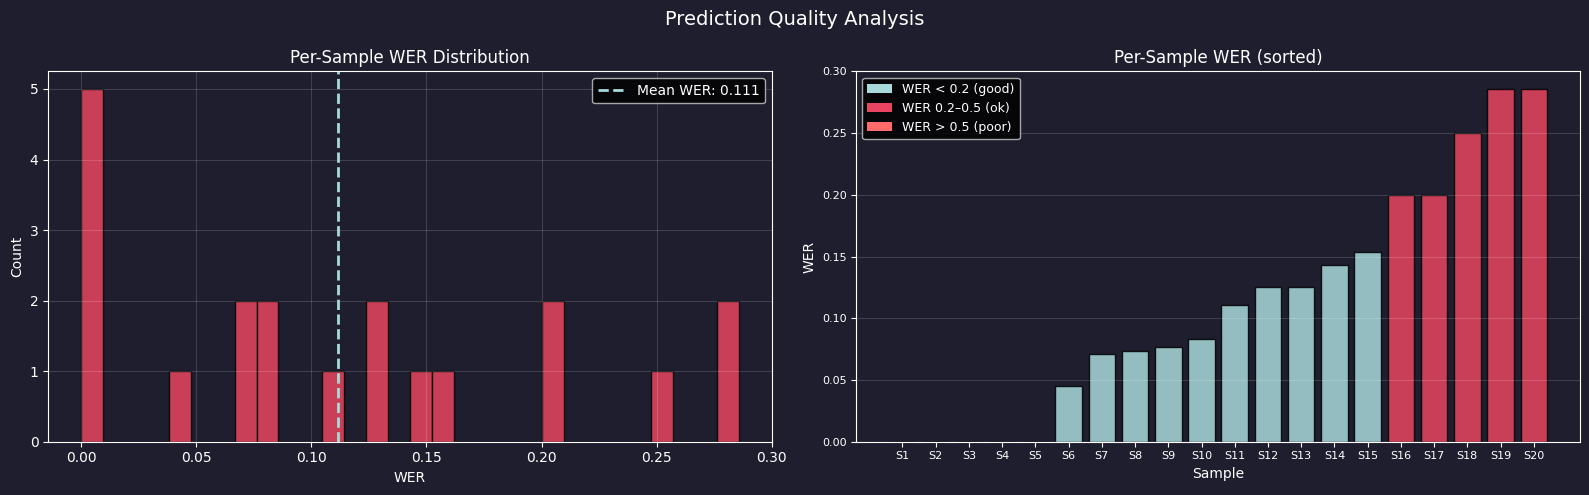


Final Summary:
  Best checkpoint : /home/ahmed/workspace/audio_speech_to_text/checkpoints/best_model.pt
  Final WER       : 10.46%
  Final CER       : 2.88%
  Visualizations  : /home/ahmed/workspace/audio_speech_to_text/viz_*.png

Week 4 complete


In [22]:
per_sample_wer = [wer(r['reference'], r['prediction']) for r in results if r['reference'].strip()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG_COLOR)
fig.suptitle('Prediction Quality Analysis', color='white', fontsize=14)

axes[0].hist(per_sample_wer, bins=30, color=ACCENT, edgecolor='black', alpha=0.85)
axes[0].axvline(np.mean(per_sample_wer), color=ACCENT2, linestyle='--', linewidth=2,
                label=f'Mean WER: {np.mean(per_sample_wer):.3f}')
axes[0].set_title('Per-Sample WER Distribution', color='white')
axes[0].set_xlabel('WER', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor(BG_COLOR)
axes[0].legend()
axes[0].grid(alpha=0.15)

sorted_results = sorted(zip(per_sample_wer, results), key=lambda x: x[0])
labels_plot    = [f'S{i+1}' for i in range(len(sorted_results))]
wers_plot      = [x[0] for x in sorted_results]
bar_colors     = [ACCENT2 if w < 0.2 else ACCENT if w < 0.5 else '#ff6b6b' for w in wers_plot]

axes[1].bar(labels_plot, wers_plot, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Per-Sample WER (sorted)', color='white')
axes[1].set_xlabel('Sample', color='white')
axes[1].set_ylabel('WER', color='white')
axes[1].tick_params(colors='white', labelsize=8)
axes[1].set_facecolor(BG_COLOR)
axes[1].grid(alpha=0.15, axis='y')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT2, label='WER < 0.2 (good)'),
    Patch(facecolor=ACCENT,  label='WER 0.2–0.5 (ok)'),
    Patch(facecolor='#ff6b6b', label='WER > 0.5 (poor)')
]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'viz_prediction_quality.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print(f'\nFinal Summary:')
print(f'  Best checkpoint : {CHECKPOINT_DIR}/best_model.pt')
print(f'  Final WER       : {final_wer*100:.2f}%')
print(f'  Final CER       : {final_cer*100:.2f}%')
print(f'  Visualizations  : {BASE_DIR}/viz_*.png')
print('\nWeek 4 complete')